In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.tools import aggregate_results

In [3]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def capitalize(s):
    return s[0].upper() + s[1:]

In [4]:
def heatmap(df, metric_cols):
    fig, axes = plt.subplots(len(metric_cols), 1, figsize=(16, 20))

    for i, ax in enumerate(axes):

        label, metric, *_ = metric_cols[i].split(" ")

        pivoted = df.pivot(index='model', columns='suite', values=metric_cols[i])
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            annot=True,
            square=True,
            yticklabels=df["model"].unique(),
            cmap="Blues",
            ax=ax,
        )

        ax.set_xticklabels(df["suite"].unique(), rotation=45)

    plt.suptitle(f"Means of {capitalize(metric)} Scores by Label", y=1)
    plt.tight_layout()
    
    return fig, ax

In [5]:
def f1_barchart(df, metric_cols):

    df = aggregate_results(res, ["model"], metric_cols, funs=["mean", "std"])
    df.columns = [" ".join(list(cols)).replace(" mean ", " ") for cols in df.columns]
    df = df.reset_index()

    # Assume your dataframe is called df
    models = df['model'].values

    # Means
    theme_mean = df['theme f1 mean'].values
    topic_mean = df['topic f1 mean'].values
    concept_mean = df['concept f1 mean'].values

    # Standard deviations
    theme_std = df['theme f1 std'].values
    topic_std = df['topic f1 std'].values
    concept_std = df['concept f1 std'].values

    # X positions
    x = np.arange(len(models))
    width = 0.25  # width of bars

    # Create plot
    fig = plt.figure()

    plt.bar(x - width, theme_mean, width, yerr=theme_std, capsize=4, label='Theme F1')
    plt.bar(x,         topic_mean, width, yerr=topic_std, capsize=4, label='Topic F1')
    plt.bar(x + width, concept_mean, width, yerr=concept_std, capsize=4, label='Concept F1')

    # Labels & formatting
    plt.xticks(x, models, rotation=45)
    plt.ylabel('F1 Score')
    plt.xlabel('Model')
    plt.title('F1 Scores by Model (with Std Dev)')
    plt.legend()

    plt.tight_layout()

    return fig

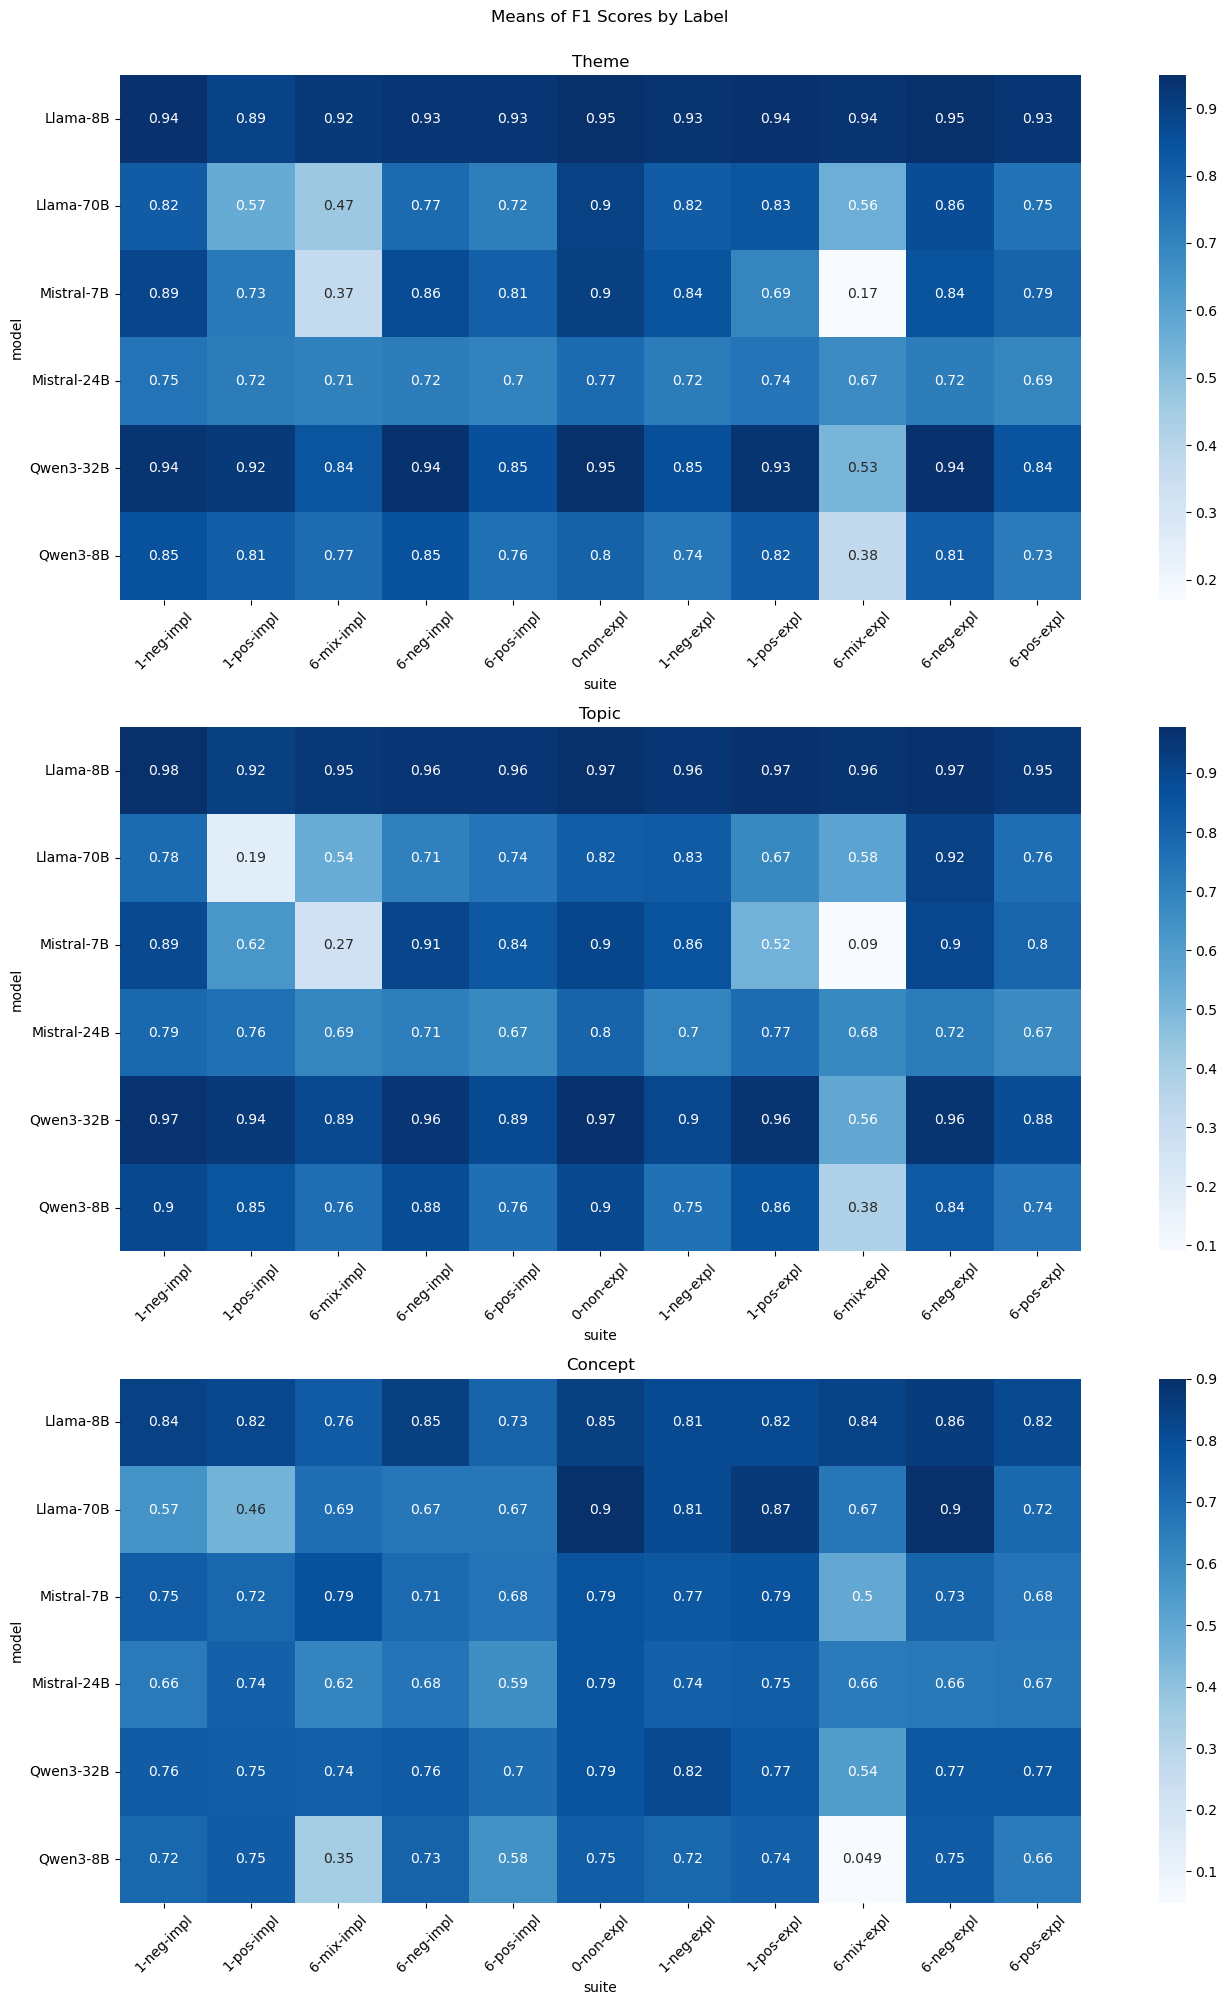

In [7]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

###
# HEATMAP F1
###
res = pd.read_csv("./data/metrics.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

fig, ax = heatmap(res, metric_cols_f1)
#plt.show()
plt.savefig("./latex/images/f1_per_suite", bbox_inches="tight")

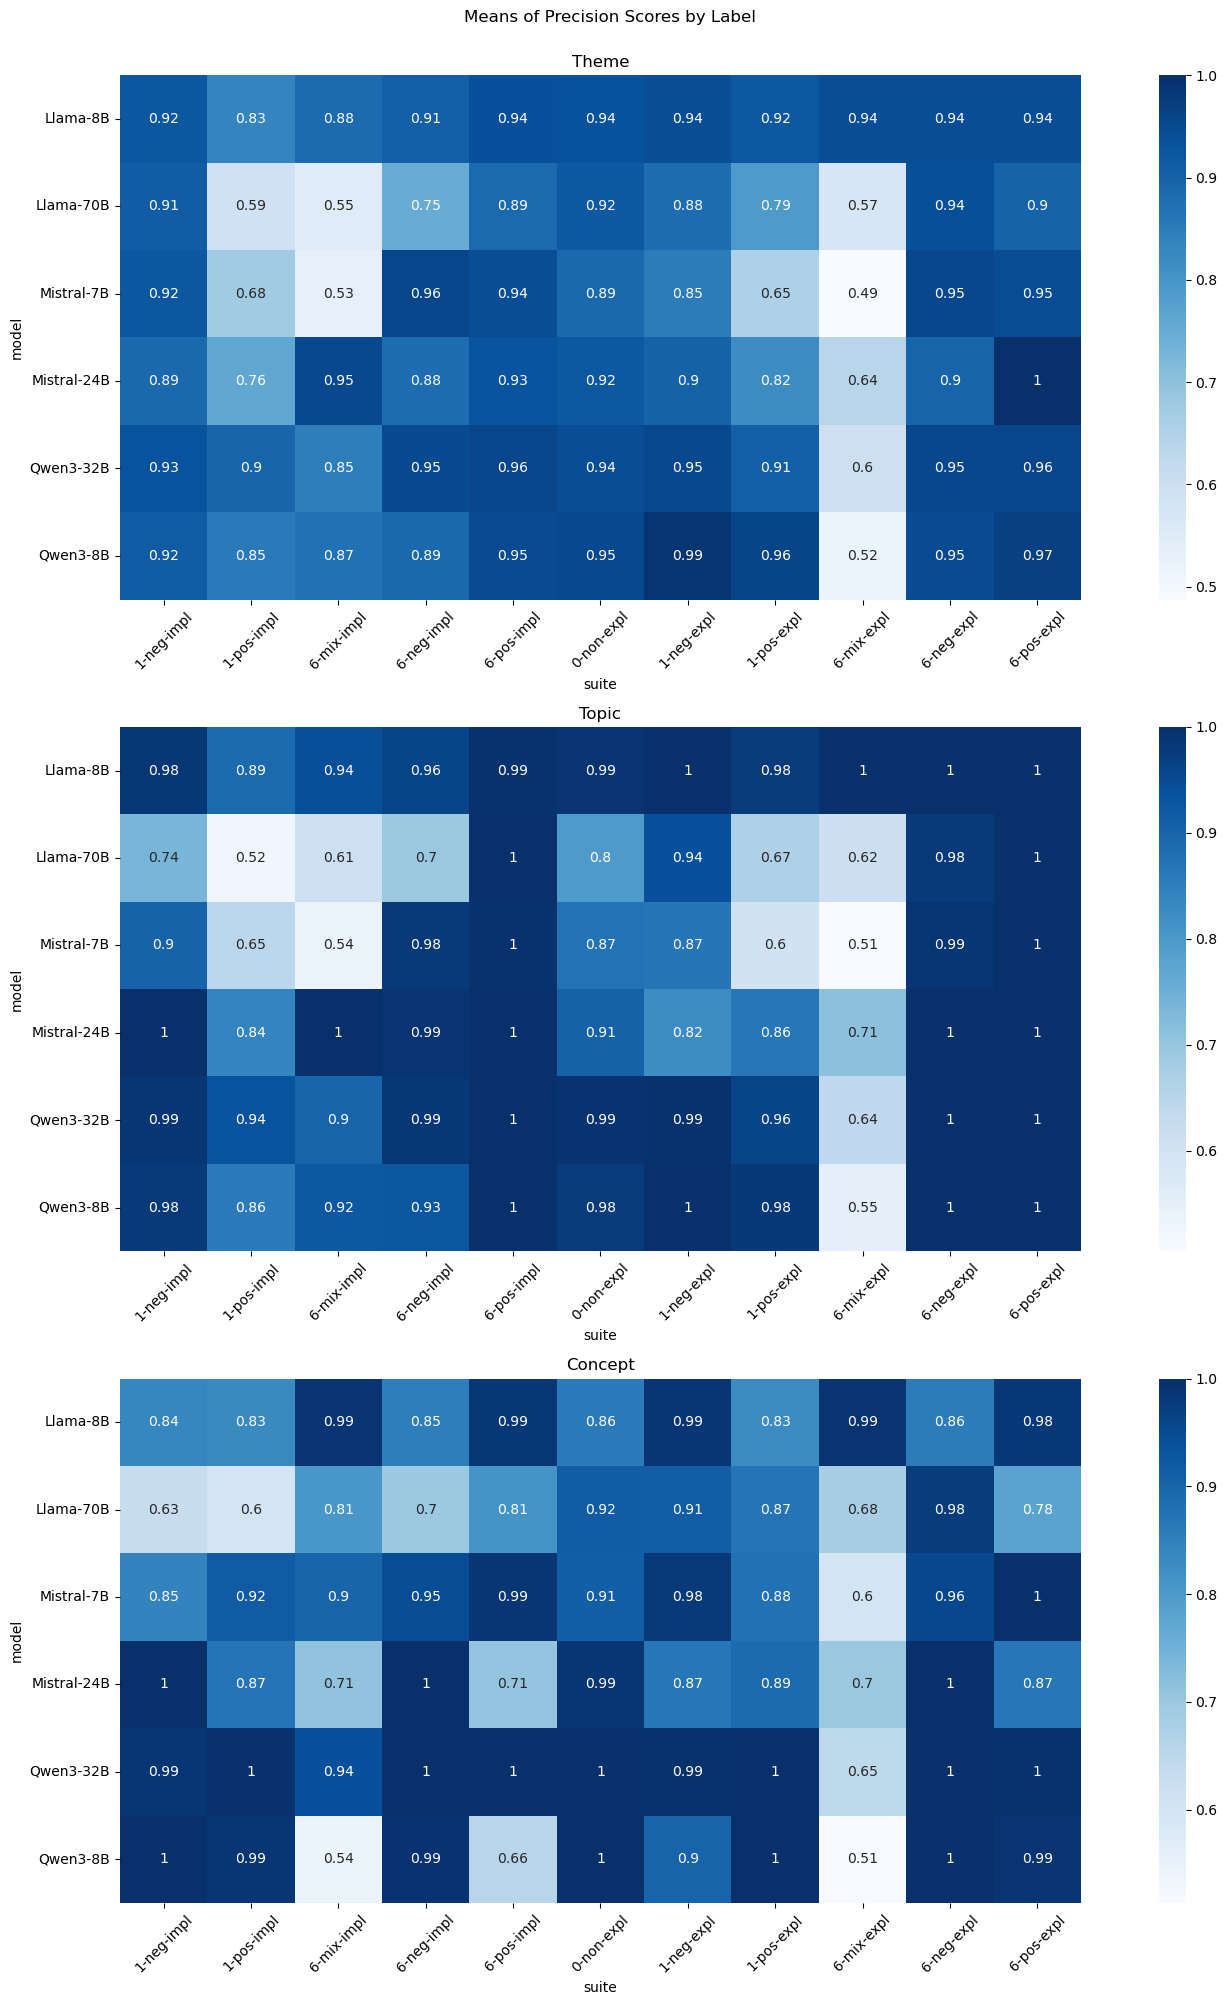

In [8]:
fig, ax = heatmap(res, metric_cols_prec)
plt.savefig("./latex/images/precision_per_suite", bbox_inches="tight")

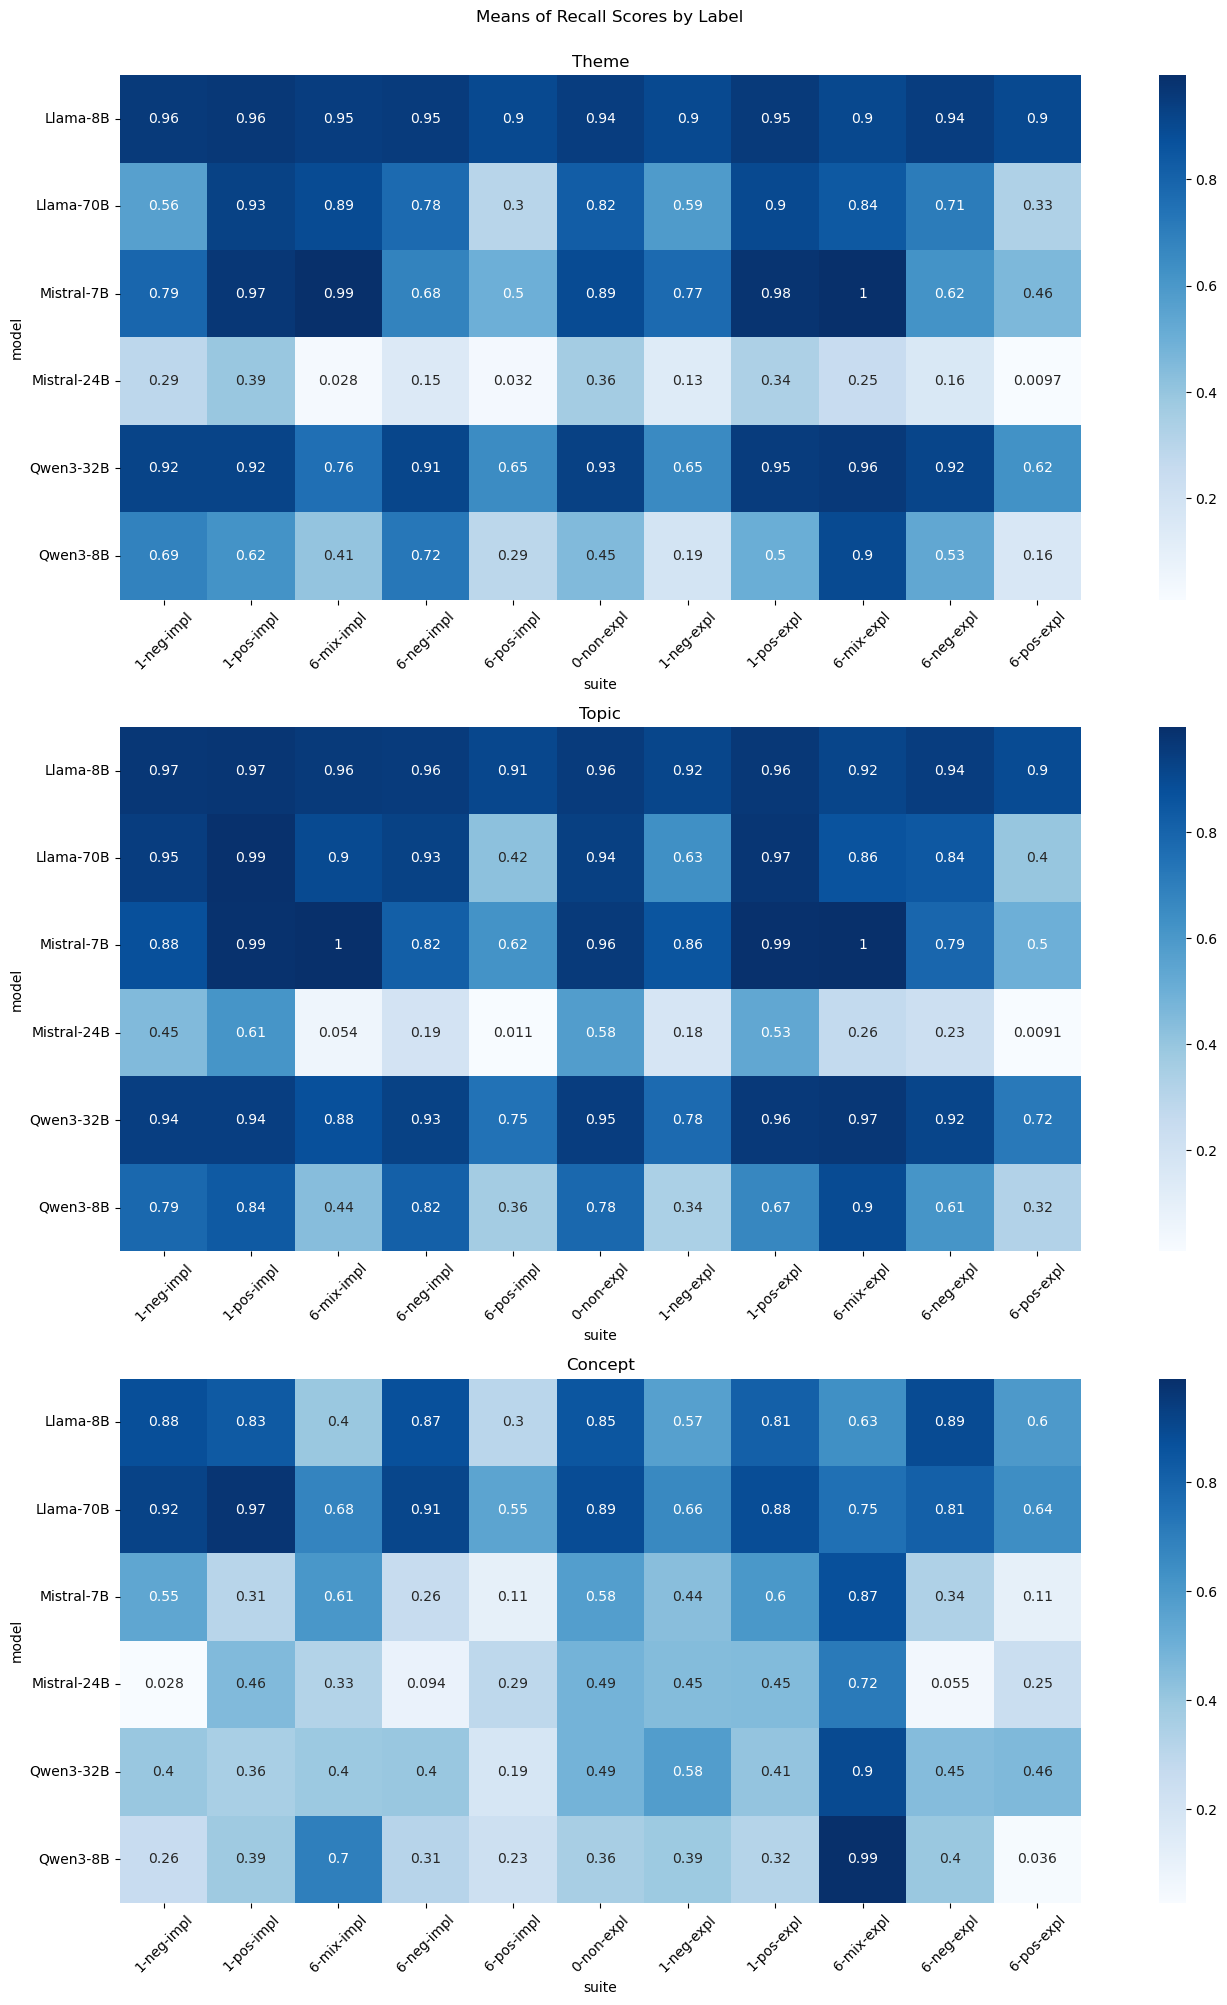

In [9]:
fig, ax = heatmap(res, metric_cols_rec)
plt.savefig("./latex/images/recall_per_suite", bbox_inches="tight")

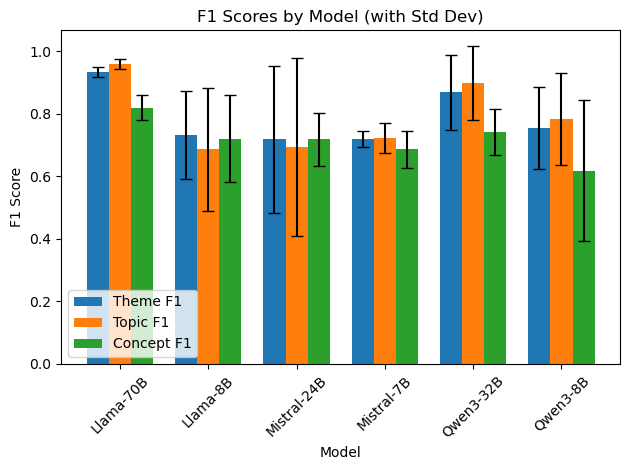

In [11]:
fig = f1_barchart(res, metric_cols_f1)

plt.savefig("./latex/images/f1_per_model.png")